# Heart Failure Outcome Prediction Using Machine Learning

## Introduction

This notebook develops and evaluates machine learning models for predicting adverse heart failure outcomes using clinical patient records.

The workflow includes dataset inspection, preprocessing, model training, evaluation, comparison and selection of the final deployment model for integration into the Flask application.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
heart_failure = pd.read_csv("/content/heart_failure.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", heart_failure.shape)

heart_failure.head()

Dataset loaded successfully.
Dataset shape: (5000, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,55.0,0,748,0,45,0,263358.03,1.3,137,1,1,88,0
1,65.0,0,56,0,25,0,305000.00,5.0,130,1,0,207,0
2,45.0,0,582,1,38,0,319000.00,0.9,140,0,0,244,0
3,60.0,1,754,1,40,1,328000.00,1.2,126,1,0,90,0
4,95.0,1,582,0,30,0,461000.00,2.0,132,1,0,50,1


# 1. Dataset Overview

The Heart Failure dataset contains demographic and clinical variables associated with patient outcomes during a recorded follow-up period. The target variable, `DEATH_EVENT`, indicates whether an adverse outcome occurred.

In [5]:
print("Columns:")
print(heart_failure.columns.tolist())

print("\nData types:")
print(heart_failure.dtypes)

print("\nMissing values:")
print(heart_failure.isnull().sum())

print("\nTarget distribution:")
print(heart_failure["DEATH_EVENT"].value_counts())

Columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Data types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex             

# 2. Data Preparation

The dataset is already numerical and contains no missing values. The predictor variables are separated from the binary target, followed by a stratified training and testing split.

In [6]:
X_failure = heart_failure.drop("DEATH_EVENT", axis=1)
y_failure = heart_failure["DEATH_EVENT"]

print("Feature matrix shape:", X_failure.shape)
print("Target shape:", y_failure.shape)

Feature matrix shape: (5000, 12)
Target shape: (5000,)


In [7]:
X_train_failure, X_test_failure, y_train_failure, y_test_failure = train_test_split(
    X_failure,
    y_failure,
    test_size=0.20,
    random_state=42,
    stratify=y_failure
)

print("Training set:", X_train_failure.shape)
print("Testing set :", X_test_failure.shape)

Training set: (4000, 12)
Testing set : (1000, 12)


In [8]:
scaler_failure = StandardScaler()

X_train_failure_scaled = scaler_failure.fit_transform(X_train_failure)
X_test_failure_scaled = scaler_failure.transform(X_test_failure)

print("Feature scaling completed.")

Feature scaling completed.


# 3. Model Development

Logistic Regression, Random Forest and XGBoost are trained using the same train-test split to support a consistent comparison.

In [9]:
failure_logistic = LogisticRegression(
    random_state=42,
    max_iter=1000
)

failure_logistic.fit(
    X_train_failure_scaled,
    y_train_failure
)

failure_logistic_pred = failure_logistic.predict(
    X_test_failure_scaled
)

print("Logistic Regression trained.")

Logistic Regression trained.


In [10]:
failure_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

failure_rf.fit(
    X_train_failure,
    y_train_failure
)

failure_rf_pred = failure_rf.predict(X_test_failure)

print("Random Forest trained.")

Random Forest trained.


In [11]:
failure_xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

failure_xgb.fit(
    X_train_failure,
    y_train_failure
)

failure_xgb_pred = failure_xgb.predict(X_test_failure)

print("XGBoost trained.")

XGBoost trained.


In [12]:
failure_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test_failure, failure_logistic_pred),
        accuracy_score(y_test_failure, failure_rf_pred),
        accuracy_score(y_test_failure, failure_xgb_pred)
    ],
    "Precision": [
        precision_score(y_test_failure, failure_logistic_pred),
        precision_score(y_test_failure, failure_rf_pred),
        precision_score(y_test_failure, failure_xgb_pred)
    ],
    "Recall": [
        recall_score(y_test_failure, failure_logistic_pred),
        recall_score(y_test_failure, failure_rf_pred),
        recall_score(y_test_failure, failure_xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test_failure, failure_logistic_pred),
        f1_score(y_test_failure, failure_rf_pred),
        f1_score(y_test_failure, failure_xgb_pred)
    ]
}).round(4)

failure_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.830,0.7416,0.7038,0.7222
1,Random Forest,0.991,0.9967,0.9745,0.9855
2,XGBoost,0.995,0.9936,0.9904,0.9920


# 1. Dataset Overview

The Heart Failure Clinical Records dataset contains demographic and clinical measurements collected from patients with heart failure. The objective is to predict whether a patient experiences a death event during the follow-up period based on clinical indicators.

In [13]:
# ============================================================
# Inspect Dataset
# ============================================================

print("Dataset Shape:")
print(heart_failure.shape)

print("\nColumns:")
print(heart_failure.columns.tolist())

print("\nData Types:")
print(heart_failure.dtypes)

print("\nMissing Values:")
print(heart_failure.isnull().sum())

print("\nTarget Distribution:")
print(heart_failure["DEATH_EVENT"].value_counts())

Dataset Shape:
(5000, 13)

Columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium       

# 2. Data Preparation

The Heart Failure dataset already contains numerical variables and no missing values. The predictor variables are separated from the binary target variable before model training.

In [14]:
# ============================================================
# Feature Matrix and Target Variable
# ============================================================

X_failure = heart_failure.drop("DEATH_EVENT", axis=1)
y_failure = heart_failure["DEATH_EVENT"]

print("Feature Matrix Shape:", X_failure.shape)
print("Target Shape:", y_failure.shape)

print("\nTarget Distribution:")
print(y_failure.value_counts())

Feature Matrix Shape: (5000, 12)
Target Shape: (5000,)

Target Distribution:
DEATH_EVENT
0    3432
1    1568
Name: count, dtype: int64


In [15]:
# ============================================================
# Split Dataset
# ============================================================

from sklearn.model_selection import train_test_split

X_train_failure, X_test_failure, y_train_failure, y_test_failure = train_test_split(
    X_failure,
    y_failure,
    test_size=0.20,
    random_state=42,
    stratify=y_failure
)

print("Training Samples:", X_train_failure.shape)
print("Testing Samples :", X_test_failure.shape)

Training Samples: (4000, 12)
Testing Samples : (1000, 12)


In [16]:
# ============================================================
# Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler_failure = StandardScaler()

X_train_failure_scaled = scaler_failure.fit_transform(X_train_failure)
X_test_failure_scaled = scaler_failure.transform(X_test_failure)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [17]:
# ============================================================
# Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

failure_logistic = LogisticRegression(
    random_state=42,
    max_iter=1000
)

failure_logistic.fit(
    X_train_failure_scaled,
    y_train_failure
)

failure_logistic_pred = failure_logistic.predict(
    X_test_failure_scaled
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [18]:
# ============================================================
# Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

failure_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

failure_rf.fit(
    X_train_failure,
    y_train_failure
)

failure_rf_pred = failure_rf.predict(X_test_failure)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [19]:
# ============================================================
# XGBoost
# ============================================================

from xgboost import XGBClassifier

failure_xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

failure_xgb.fit(
    X_train_failure,
    y_train_failure
)

failure_xgb_pred = failure_xgb.predict(X_test_failure)

print("XGBoost trained successfully.")

XGBoost trained successfully.


# 3. Model Evaluation and Comparison

The three trained models are compared using accuracy, precision, recall and F1-score. The same test dataset is used for each model to maintain a consistent evaluation.

In [20]:
# ============================================================
# Model Comparison
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

failure_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test_failure, failure_logistic_pred),
        accuracy_score(y_test_failure, failure_rf_pred),
        accuracy_score(y_test_failure, failure_xgb_pred)
    ],
    "Precision": [
        precision_score(y_test_failure, failure_logistic_pred),
        precision_score(y_test_failure, failure_rf_pred),
        precision_score(y_test_failure, failure_xgb_pred)
    ],
    "Recall": [
        recall_score(y_test_failure, failure_logistic_pred),
        recall_score(y_test_failure, failure_rf_pred),
        recall_score(y_test_failure, failure_xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test_failure, failure_logistic_pred),
        f1_score(y_test_failure, failure_rf_pred),
        f1_score(y_test_failure, failure_xgb_pred)
    ]
}).round(4)

failure_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.830,0.7416,0.7038,0.7222
1,Random Forest,0.991,0.9967,0.9745,0.9855
2,XGBoost,0.995,0.9936,0.9904,0.9920


In [21]:
# ============================================================
# Detailed XGBoost Evaluation
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

print("XGBoost Classification Report\n")
print(classification_report(y_test_failure, failure_xgb_pred))

failure_xgb_cm = confusion_matrix(
    y_test_failure,
    failure_xgb_pred
)

print("\nConfusion Matrix:")
print(failure_xgb_cm)

XGBoost Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       686
           1       0.99      0.99      0.99       314

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000


Confusion Matrix:
[[684   2]
 [  3 311]]


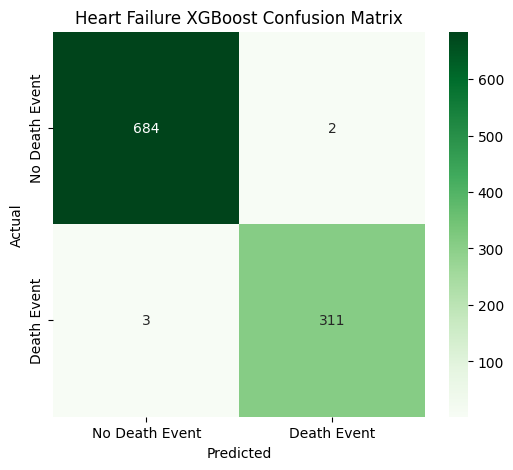

In [22]:
# ============================================================
# XGBoost Confusion Matrix
# ============================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    failure_xgb_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Death Event", "Death Event"],
    yticklabels=["No Death Event", "Death Event"]
)

plt.title("Heart Failure XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
# ============================================================
# Save Deployment Model
# ============================================================

import joblib

joblib.dump(
    failure_xgb,
    "heart_failure_model.pkl"
)

print("Heart Failure deployment model saved successfully.")

Heart Failure deployment model saved successfully.


In [25]:
# ============================================================
# Verify Saved Model
# ============================================================

saved_model = joblib.load("heart_failure_model.pkl")

print(type(saved_model))

<class 'xgboost.sklearn.XGBClassifier'>


# 4. Conclusion

This notebook developed a machine learning model for predicting adverse heart failure outcomes using clinical patient data.

Three classification algorithms were evaluated using identical training and testing data. XGBoost achieved the highest overall performance and was selected as the deployment model for the Heart Failure module of the Flask application.

The trained model was exported using Joblib and integrated into the multi-dataset Heart Disease Prediction System developed for this project.